# Name: Pallavi dakka
# Student ID: A00075097
# Title: Smart Home Appliance Usage Forecasting

Link of the dataset: https://www.kaggle.com/datasets/kyleahmurphy/uk-electrical-load

In [ ]:
# IMPORT LIBRARIES


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller
from glob import glob

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Data loading

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/archive.zip"
extract_path = "/content/refit_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)

Dataset extracted to: /content/refit_data


# Preparing the Data

In [ ]:
import pandas as pd
import numpy as np
from glob import glob
import os

# DATA PATH after extraction
DATA_PATH = "/content/refit_data"

csv_files = glob(os.path.join(DATA_PATH, "*.csv"))

house_data = {}

for file in csv_files:

    df = pd.read_csv(file)

    df.columns = df.columns.str.strip()

    # detect datetime column
    date_col = df.columns[0]

    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

    df = df.dropna(subset=[date_col])

    df = df.sort_values(date_col)

    df = df.set_index(date_col)

    # resample to 30 minutes
    df = df.resample("30min").mean().ffill()

    # keep last 180 days
    df = df.loc[df.index >= df.index.max() - pd.Timedelta(days=180)]

    # cyclical time features
    df["Hour_sin"] = np.sin(2*np.pi*df.index.hour/24)
    df["Hour_cos"] = np.cos(2*np.pi*df.index.hour/24)

    df["Day_sin"] = np.sin(2*np.pi*df.index.dayofweek/7)
    df["Day_cos"] = np.cos(2*np.pi*df.index.dayofweek/7)

    house_data[os.path.basename(file)] = df.astype(np.float32)

print("Total houses:", len(house_data))

Total houses: 20


In [ ]:
# FEATURES


sample_house = list(house_data.keys())[0]
df_sample = house_data[sample_house]

# appliance columns
appliance_cols = [c for c in df_sample.columns if c.startswith("Appliance")]

# input features
features = appliance_cols + [
    "Hour_sin",
    "Hour_cos",
    "Day_sin",
    "Day_cos"
]

# prediction targets
target_cols = appliance_cols

print("Appliance columns:", appliance_cols)
print("Number of appliances:", len(appliance_cols))

Appliance columns: ['Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9']
Number of appliances: 9


               Unix    Aggregate   Appliance1   Appliance2   Appliance3  \
count  8.641000e+03  8641.000000  8641.000000  8641.000000  8641.000000   
mean   1.428508e+09   458.885529    35.011963     9.724896     0.094145   
std    4.462042e+06   411.387939    34.218510    17.743557     2.755334   
min    1.420770e+09   123.055763     0.000000     0.000000     0.000000   
25%    1.424658e+09   238.627304     5.419117     0.000000     0.000000   
50%    1.428546e+09   332.355560    27.969696     0.000000     0.000000   
75%    1.432434e+09   489.118530    46.809044    16.891790     0.000000   
max    1.436321e+09  5022.924316   214.563431   142.342407   126.738808   

        Appliance4   Appliance5   Appliance6   Appliance7   Appliance8  \
count  8641.000000  8641.000000  8641.000000  8641.000000  8641.000000   
mean      0.340191    14.720621    21.379299     3.731704    56.210724   
std       0.705519   113.304749   146.478073     8.558598    73.150360   
min       0.000000     0.000

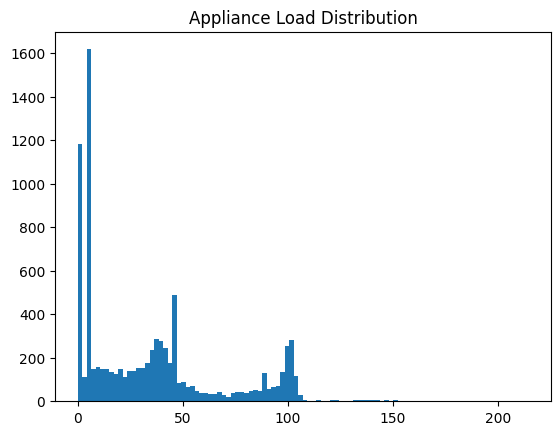

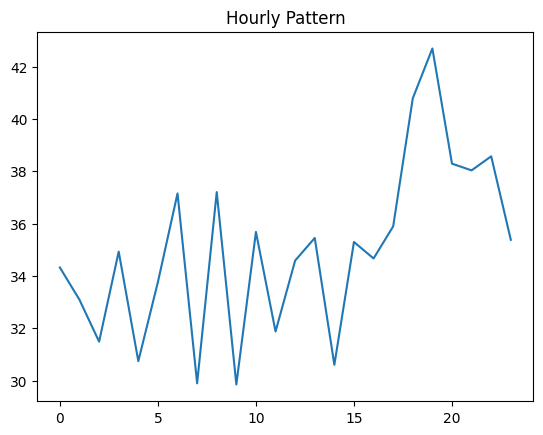

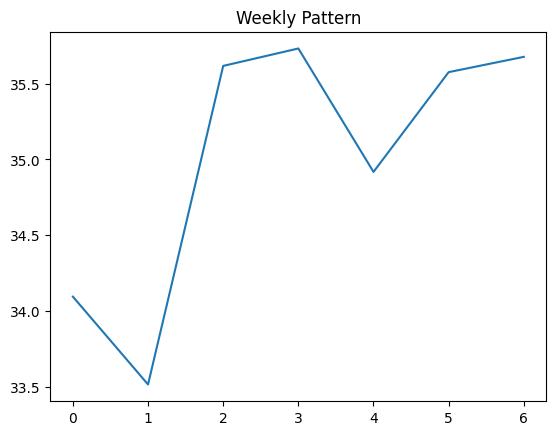

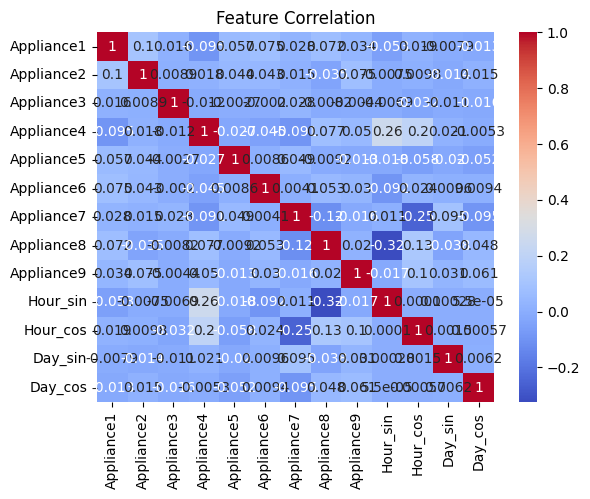

ADF p-value: 1.5650583112870124e-07


In [ ]:
# EDA

df = df_sample

print(df.describe())

plt.hist(df[target_cols[0]],bins=100)
plt.title("Appliance Load Distribution")
plt.show()

hourly = df.groupby(df.index.hour)[target_cols[0]].mean()

plt.plot(hourly)
plt.title("Hourly Pattern")
plt.show()

weekly = df.groupby(df.index.dayofweek)[target_cols[0]].mean()

plt.plot(weekly)
plt.title("Weekly Pattern")
plt.show()

sns.heatmap(df[features].corr(),annot=True,cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

result = adfuller(df[target_cols[0]])
print("ADF p-value:",result[1])

In [ ]:
# CROSS HOUSE SPLIT


houses = list(house_data.keys())

split = int(len(houses)*0.8)

train_houses = houses[:split]
test_houses = houses[split:]

In [ ]:
# SCALING

train_concat = pd.concat([house_data[h][features] for h in train_houses])

scaler = MinMaxScaler()
scaler.fit(train_concat)

scaled_train={}
scaled_test={}

for h in train_houses:
    scaled_train[h]=scaler.transform(house_data[h][features])

for h in test_houses:
    scaled_test[h]=scaler.transform(house_data[h][features])

In [ ]:
# DATASET

SEQ_LENGTH = 96

class StreamingDataset(Dataset):

    def __init__(self,house_dict,seq_length):

        self.house_dict=house_dict
        self.seq_length=seq_length
        self.indices=[]

        for h,data in house_dict.items():
            for i in range(len(data)-seq_length):
                self.indices.append((h,i))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self,idx):

        h,i = self.indices[idx]

        data=self.house_dict[h]

        X=data[i:i+self.seq_length]

        y=data[i+self.seq_length,:len(target_cols)]

        return (
            torch.tensor(X,dtype=torch.float32),
            torch.tensor(y,dtype=torch.float32)
        )

train_dataset=StreamingDataset(scaled_train,SEQ_LENGTH)
test_dataset=StreamingDataset(scaled_test,SEQ_LENGTH)

train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)


# Defining the Deep-Learning Model

In [ ]:
#  AUTOENCODER


class UsageAutoencoder(nn.Module):

    def __init__(self,input_size):

        super().__init__()

        self.encoder=nn.Sequential(
            nn.Linear(input_size,128),
            nn.ReLU(),
            nn.Linear(128,64)
        )

        self.decoder=nn.Sequential(
            nn.Linear(64,128),
            nn.ReLU(),
            nn.Linear(128,input_size)
        )

    def forward(self,x):

        b,s,f=x.shape

        x=x.view(b*s,f)

        latent=self.encoder(x)

        recon=self.decoder(latent)

        recon=recon.view(b,s,f)

        return recon,latent

autoencoder=UsageAutoencoder(len(features)).to(device)

criterion=nn.MSELoss()
optimizer=torch.optim.Adam(autoencoder.parameters(),lr=0.001)

for epoch in range(5):

    loss_total=0

    for xb,_ in train_loader:

        xb=xb.to(device)

        optimizer.zero_grad()

        recon,_=autoencoder(xb)

        loss=criterion(recon,xb)

        loss.backward()

        optimizer.step()

        loss_total+=loss.item()

    print("Autoencoder epoch",epoch+1,loss_total/len(train_loader))

Autoencoder epoch 1 0.00042606901605143297
Autoencoder epoch 2 5.0186700400056815e-06
Autoencoder epoch 3 4.230467444468552e-06
Autoencoder epoch 4 3.7783119446327946e-06
Autoencoder epoch 5 3.4890288626401217e-06


In [ ]:
#  ATTENTION LSTM


class AttentionLSTM(nn.Module):

    def __init__(self,input_size,output_size):

        super().__init__()

        self.lstm=nn.LSTM(input_size,64,2,batch_first=True)

        self.attn=nn.Linear(64,1)

        self.fc=nn.Linear(64,output_size)

    def forward(self,x):

        out,_=self.lstm(x)

        weights=torch.softmax(self.attn(out),dim=1)

        context=torch.sum(weights*out,dim=1)

        return self.fc(context)


In [ ]:
# TEMPORAL CNN


class TemporalCNN(nn.Module):

    def __init__(self,input_size,output_size):

        super().__init__()

        self.conv1=nn.Conv1d(input_size,64,3,padding=2,dilation=2)
        self.conv2=nn.Conv1d(64,64,3,padding=4,dilation=4)

        self.relu=nn.ReLU()

        self.pool=nn.AdaptiveAvgPool1d(1)

        self.fc=nn.Linear(64,output_size)

    def forward(self,x):

        x=x.permute(0,2,1)

        x=self.relu(self.conv1(x))
        x=self.relu(self.conv2(x))

        x=self.pool(x).squeeze(-1)

        return self.fc(x)


In [ ]:
#TRAIN FUNCTION


def train_model(model,epochs=10):

    model=model.to(device)

    optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

    criterion=nn.MSELoss()

    for epoch in range(epochs):

        model.train()

        train_loss=0

        for xb,yb in train_loader:

            xb,yb=xb.to(device),yb.to(device)

            optimizer.zero_grad()

            pred=model(xb)

            loss=criterion(pred,yb)

            loss.backward()

            optimizer.step()

            train_loss+=loss.item()

        train_loss/=len(train_loader)

        print("Epoch",epoch+1,"Loss",train_loss)

    return model

# Training and Fine-Tuning  Models

In [ ]:
# TRAIN MODELS


att_model=train_model(
    AttentionLSTM(len(features),len(target_cols))
)



Epoch 1 Loss 0.0013447540248340837
Epoch 2 Loss 0.0012834522993726504
Epoch 3 Loss 0.0012359956097101324
Epoch 4 Loss 0.0011909602486299658
Epoch 5 Loss 0.0011590477839799685
Epoch 6 Loss 0.0011324549666352926
Epoch 7 Loss 0.0011126240496714117
Epoch 8 Loss 0.0011012924695931688
Epoch 9 Loss 0.0010919541127575258
Epoch 10 Loss 0.0010755259198865796


In [ ]:
cnn_model=train_model(
    TemporalCNN(len(features),len(target_cols))
)



Epoch 1 Loss 0.0012951192986210723
Epoch 2 Loss 0.0010832203122414584
Epoch 3 Loss 0.0010021344500492505
Epoch 4 Loss 0.0009758978445514891
Epoch 5 Loss 0.0009636003289865343
Epoch 6 Loss 0.000953528225657086
Epoch 7 Loss 0.0009444047121502041
Epoch 8 Loss 0.0009367732425526224
Epoch 9 Loss 0.0009293415266160495
Epoch 10 Loss 0.0009218152111688853


In [ ]:
# EVALUATION


def evaluate(model):

    model.eval()

    preds=[]
    true=[]

    with torch.no_grad():

        for xb,yb in test_loader:

            xb=xb.to(device)

            out=model(xb).cpu().numpy()

            preds.append(out)

            true.append(yb.numpy())

    preds=np.vstack(preds)
    true=np.vstack(true)

    mae=mean_absolute_error(true,preds)
    rmse=np.sqrt(mean_squared_error(true,preds))

    epsilon = 1e-8
    mape=np.mean(np.abs((true-preds)/(true+epsilon)))*100

    r2=r2_score(true,preds)

    return mae,rmse,mape,r2,true,preds

models={
"AttentionLSTM":att_model,
"TemporalCNN":cnn_model
}

results={}

for name,model in models.items():

    mae,rmse,mape,r2,_,_=evaluate(model)

    results[name]=[mae,rmse,mape,r2]

results_df=pd.DataFrame(
    results,
    index=["MAE","RMSE","MAPE","R2"]
).T

print(results_df)

                    MAE      RMSE        MAPE        R2
AttentionLSTM  0.016116  0.055047  54129976.0  0.104237
TemporalCNN    0.013567  0.052776  44955408.0  0.179653


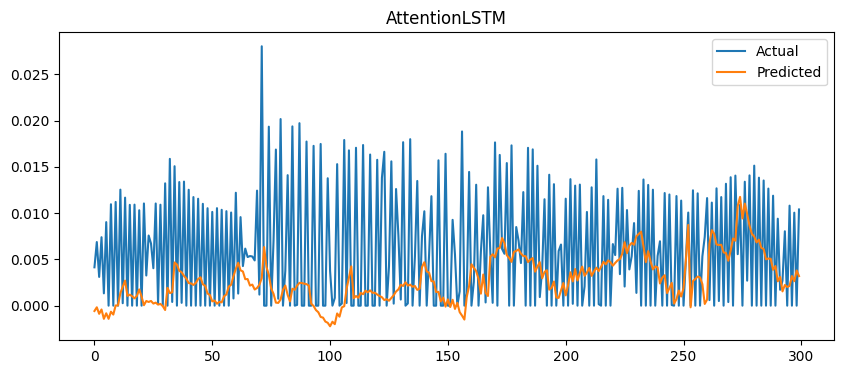

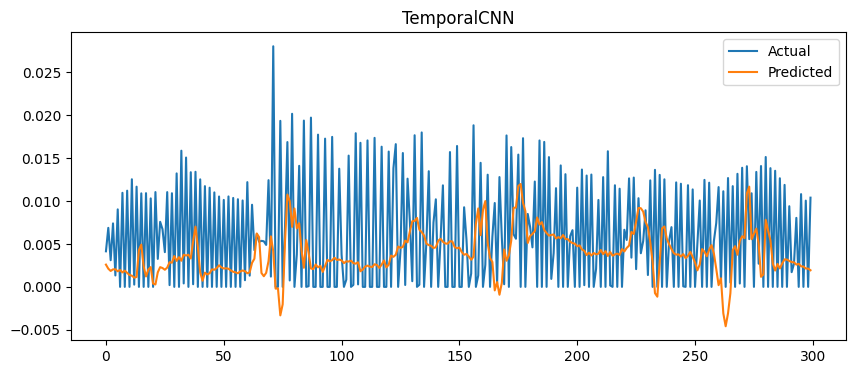

In [ ]:

#PREDICTION VISUALIZATION


for name,model in models.items():

    _,_,_,_,true,pred=evaluate(model)

    plt.figure(figsize=(10,4))

    plt.plot(true[:300,0],label="Actual")

    plt.plot(pred[:300,0],label="Predicted")

    plt.title(name)

    plt.legend()

    plt.show()

In [ ]:

# HYPERPARAMETER FINE TUNING


from itertools import product

param_grid = {
    "hidden_size": [64, 128],
    "num_layers": [1, 2],
    "learning_rate": [0.001, 0.0005]
}

# Tunable Attention LSTM
class TunableAttentionLSTM(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers, output_size):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True
        )

        self.attn = nn.Linear(hidden_size, 1)

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):

        out, _ = self.lstm(x)

        weights = torch.softmax(self.attn(out), dim=1)

        context = torch.sum(weights * out, dim=1)

        return self.fc(context)


def train_and_validate(hidden_size, num_layers, lr):

    print(f"\nTraining: hidden={hidden_size}, layers={num_layers}, lr={lr}")

    model = TunableAttentionLSTM(
        len(features),
        hidden_size,
        num_layers,
        len(target_cols)
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    criterion = nn.MSELoss()

    epochs = 3   # reduced for faster tuning

    for epoch in range(epochs):

        model.train()

        train_loss = 0

        for xb, yb in train_loader:

            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()

            pred = model(xb)

            loss = criterion(pred, yb)

            loss.backward()

            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        print("Epoch", epoch+1, "Loss:", train_loss)

    # Validation
    model.eval()

    preds = []
    true = []

    with torch.no_grad():

        for xb, yb in test_loader:

            xb = xb.to(device)

            out = model(xb).cpu().numpy()

            preds.append(out)

            true.append(yb.numpy())

    preds = np.vstack(preds)
    true = np.vstack(true)

    rmse = np.sqrt(mean_squared_error(true, preds))

    return rmse, model


best_rmse = float("inf")
best_model = None
best_params = None


# Run grid search
for hidden_size, num_layers, lr in product(
    param_grid["hidden_size"],
    param_grid["num_layers"],
    param_grid["learning_rate"]
):

    rmse, model = train_and_validate(hidden_size, num_layers, lr)

    print("Validation RMSE:", rmse)

    if rmse < best_rmse:

        best_rmse = rmse
        best_model = model

        best_params = {
            "hidden_size": hidden_size,
            "num_layers": num_layers,
            "learning_rate": lr
        }


print("\n============================")
print("BEST HYPERPARAMETERS")
print(best_params)
print("BEST RMSE:", best_rmse)
print("============================")


Training: hidden=64, layers=1, lr=0.001
Epoch 1 Loss: 0.0013374522935678287
Epoch 2 Loss: 0.0012851520432260518
Epoch 3 Loss: 0.0012688942688543073
Validation RMSE: 0.05062937261762339

Training: hidden=64, layers=1, lr=0.0005
Epoch 1 Loss: 0.0013494891625065763
Epoch 2 Loss: 0.0012875882345601013
Epoch 3 Loss: 0.0012759915618351801
Validation RMSE: 0.049765080242379266

Training: hidden=64, layers=2, lr=0.001
Epoch 1 Loss: 0.0013385918117166727
Epoch 2 Loss: 0.0012892426777922669
Epoch 3 Loss: 0.0012605804585809337
Validation RMSE: 0.05294223940972038

Training: hidden=64, layers=2, lr=0.0005
Epoch 1 Loss: 0.0013634104617311499
Epoch 2 Loss: 0.0012937629130258665
Epoch 3 Loss: 0.0012742140861902271
Validation RMSE: 0.052504708268435896

Training: hidden=128, layers=1, lr=0.001
Epoch 1 Loss: 0.0013232332861123216
Epoch 2 Loss: 0.001282522353241322
Epoch 3 Loss: 0.0012487782053968322
Validation RMSE: 0.05019018169259792

Training: hidden=128, layers=1, lr=0.0005
Epoch 1 Loss: 0.0013373